In [50]:
import pandas as pd
import statsmodels.api as sm

In [38]:
data_df = pd.read_csv('../data/valid_comments.csv')
data_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6447646 entries, 0 to 6447645
Data columns (total 9 columns):
 #   Column                   Dtype  
---  ------                   -----  
 0   author                   object 
 1   post_id                  object 
 2   comment_id               object 
 3   post_title_sentiment     object 
 4   post_title_score         float64
 5   post_body_sentiment      object 
 6   post_body_score          float64
 7   comment_sentiment_type   object 
 8   comment_sentiment_value  float64
dtypes: float64(3), object(6)
memory usage: 442.7+ MB


In [39]:
user_comments_on_neutral_posts_df = pd.read_csv('../data/user_comments_on_neutral_posts.csv')
user_comments_on_neutral_posts_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22771 entries, 0 to 22770
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   user           22771 non-null  object
 1   comment_type   22771 non-null  object
 2   comment_value  22771 non-null  object
dtypes: object(3)
memory usage: 533.8+ KB


In [40]:
values = []

for i in range(len(user_comments_on_neutral_posts_df)):
    user_id = user_comments_on_neutral_posts_df.iloc[i]['user']
    comment_types = user_comments_on_neutral_posts_df.iloc[i]['comment_type'].split(' ')
    comment_values = list(map(float, user_comments_on_neutral_posts_df.iloc[i]['comment_value'].split(' ')))

    user_emotion = []
    for comment_type, comment_value in zip(comment_types, comment_values):
        if comment_type == 'positive':
            user_emotion.append(comment_value)
        elif comment_type == 'negative':
            user_emotion.append(-comment_value)
        else:
            user_emotion.append(0)

    values.append(sum(user_emotion) / len(user_emotion))

user_comments_on_neutral_posts_df['user_emotion'] = values

In [41]:
user_comments_on_neutral_posts_df

,user,comment_type,comment_value,user_emotion
0,------__------------,negative negative negative neutral neutral pos...,0.8 0.9 0.52 0.62 0.58 0.54 0.82 0.5 0.78 0.63...,-0.276250
1,-----iMartijn-----,negative neutral neutral negative negative neg...,0.94 0.52 0.64 0.82 0.82 0.67 0.69 0.71 0.73 0...,-0.391667
2,--sheogorath--,negative neutral neutral neutral negative neut...,0.66 0.65 0.55 0.5 0.73 0.49 0.8 0.53 0.67 0.7...,-0.329524
3,-42069-,negative positive negative negative negative n...,0.57 0.86 0.89 0.58 0.53 0.75 0.79 0.98 0.78 0...,-0.460625
4,-ACHTUNG-,negative neutral neutral negative neutral nega...,0.54 0.48 0.65 0.93 0.82 0.82 0.89 0.56 0.52,-0.353333
...,...,...,...,...
22766,zwifter11,neutral negative negative negative negative ne...,0.72 0.85 0.58 0.8 0.57 0.75 0.87 0.88 0.67 0....,-0.403095
22767,zxTheIronLungxz,negative positive neutral negative neutral neg...,0.57 0.9 0.5 0.87 0.41 0.91 0.55 0.5 0.6 0.86 ...,-0.390714
22768,zxh01,negative positive negative negative negative n...,0.78 0.65 0.8 0.84 0.62 0.79 0.71,-0.555714
22769,zztop610,neutral neutral neutral negative neutral negat...,0.91 0.73 0.55 0.89 0.84 0.7 0.74 0.87 0.8 0.9...,-0.200400


In [42]:
# map user to user_emotion
user_list = user_comments_on_neutral_posts_df['user'].tolist()
user_emotion_list = user_comments_on_neutral_posts_df['user_emotion'].tolist()

user_emotion_dict = dict(zip(user_list, user_emotion_list))

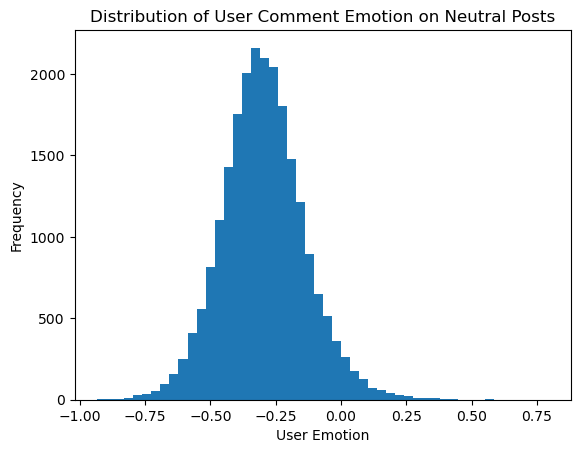

In [43]:
# draw the distribution of user_emotion_list
import matplotlib.pyplot as plt
plt.hist(user_emotion_list, bins=50)
plt.xlabel('User Emotion')
plt.ylabel('Frequency')
plt.title('Distribution of User Comment Emotion on Neutral Posts')
plt.show()


In [44]:
data_df.head()

,author,post_id,comment_id,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,comment_sentiment_type,comment_sentiment_value
0,takatori,t3_1l707d,cbwcf4j,positive,0.69,positive,0.40,neutral,0.51
1,Jaymez82,t3_1kzky0,cc1apv7,negative,0.86,negative,0.83,positive,0.54
2,Jaymez82,t3_1la1oq,cc1asj5,negative,0.65,negative,0.41,negative,0.75
3,apocolypticbosmer,t3_1lp37n,cc1hay4,negative,0.93,neutral,0.89,neutral,0.92
4,Jaymez82,t3_1kv0lj,cc2jorr,positive,0.91,positive,0.40,positive,0.88


In [45]:
regression_df = data_df[['comment_sentiment_type', 'comment_sentiment_value', 'post_title_sentiment', 'post_title_score', 'post_body_sentiment', 'post_body_score', 'author']]
regression_df.head()

,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author
0,neutral,0.51,positive,0.69,positive,0.40,takatori
1,positive,0.54,negative,0.86,negative,0.83,Jaymez82
2,negative,0.75,negative,0.65,negative,0.41,Jaymez82
3,neutral,0.92,negative,0.93,neutral,0.89,apocolypticbosmer
4,positive,0.88,positive,0.91,positive,0.40,Jaymez82


In [46]:
# map the "postiv" to 1, "negative" to -1, "neutral" to 0
regression_df['post_title_sentiment'] = regression_df['post_title_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df['post_body_sentiment'] = regression_df['post_body_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df['comment_sentiment_type'] = regression_df['comment_sentiment_type'].map({'positive': 1, 'negative': -1, 'neutral': 0})
regression_df.head()



/var/folders/dx/2ybxmrds0756ksq2t28pxqn00000gn/T/ipykernel_1811/517285301.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regression_df['post_title_sentiment'] = regression_df['post_title_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
/var/folders/dx/2ybxmrds0756ksq2t28pxqn00000gn/T/ipykernel_1811/517285301.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regression_df['post_body_sentiment'] = regression_df['post_body_sentiment'].map({'positive': 1, 'negative': -1, 'neutral': 0})
/var

,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author
0,0,0.51,1,0.69,1,0.40,takatori
1,1,0.54,-1,0.86,-1,0.83,Jaymez82
2,-1,0.75,-1,0.65,-1,0.41,Jaymez82
3,0,0.92,-1,0.93,0,0.89,apocolypticbosmer
4,1,0.88,1,0.91,1,0.40,Jaymez82


In [47]:
# create a new column, which is the product of comment_sentiment_type and comment_sentiment_value
regression_df['comment'] = regression_df['comment_sentiment_type'] * regression_df['comment_sentiment_value']
regression_df['post_title'] = regression_df['post_title_sentiment'] * regression_df['post_title_score']
regression_df['post_body'] = regression_df['post_body_sentiment'] * regression_df['post_body_score']
regression_df.head()



/var/folders/dx/2ybxmrds0756ksq2t28pxqn00000gn/T/ipykernel_1811/2503081984.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  regression_df['comment'] = regression_df['comment_sentiment_type'] * regression_df['comment_sentiment_value']


,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment,post_title,post_body
0,0,0.51,1,0.69,1,0.40,takatori,0.00,0.69,0.40
1,1,0.54,-1,0.86,-1,0.83,Jaymez82,0.54,-0.86,-0.83
2,-1,0.75,-1,0.65,-1,0.41,Jaymez82,-0.75,-0.65,-0.41
3,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,0.00,-0.93,0.00
4,1,0.88,1,0.91,1,0.40,Jaymez82,0.88,0.91,0.40


In [49]:
# create a column user_emotion
regression_df['user_base_emotion'] = regression_df['author'].map(user_emotion_dict)
regression_df.head()


,comment_sentiment_type,comment_sentiment_value,post_title_sentiment,post_title_score,post_body_sentiment,post_body_score,author,comment,post_title,post_body,user_base_emotion
0,0,0.51,1,0.69,1,0.40,takatori,0.00,0.69,0.40,-0.245333
1,1,0.54,-1,0.86,-1,0.83,Jaymez82,0.54,-0.86,-0.83,-0.326667
2,-1,0.75,-1,0.65,-1,0.41,Jaymez82,-0.75,-0.65,-0.41,-0.326667
3,0,0.92,-1,0.93,0,0.89,apocolypticbosmer,0.00,-0.93,0.00,-0.446250
4,1,0.88,1,0.91,1,0.40,Jaymez82,0.88,0.91,0.40,-0.326667


In [52]:
# conduct regression
# y is comment
# x is user_base_emotion, post_title, post_body
# add a constant term to the independent variables
y = regression_df['comment']
X = regression_df[['user_base_emotion', 'post_title', 'post_body']]
X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

In [53]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                comment   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                 8.222e+04
Date:                Sun, 25 May 2025   Prob (F-statistic):               0.00
Time:                        21:02:25   Log-Likelihood:            -5.0372e+06
No. Observations:             6447646   AIC:                         1.007e+07
Df Residuals:                 6447642   BIC:                         1.007e+07
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                -0.0888      0.00